# 🕐 Temporal Split EDA — Saheeh Masr
**Graduation Project 2026 — Arabic Fake News Detection**

**Goal:** Determine whether splitting Saheeh Masr by date (early → training, late → unseen test) is a meaningful test of generalization, or whether early/late periods are too similar to matter.

This must run and be reviewed **before** building the temporal-split training notebook — exactly the same EDA-first logic used for the original VERA/AraFacts/Saheeh Masr analysis.

### What This Notebook Checks
1. Date coverage — how many rows are usable
2. Label balance across time — confound check
3. Vocabulary/topic drift across time — is there real "newness" in the late period?
4. Named entity overlap across time — direct test of whether late period has genuinely new entities
5. Recommended cutoff date and resulting split sizes

---
## 1. Setup

In [ ]:
!pip install -q pandas numpy matplotlib seaborn arabic_reshaper python-bidi scikit-learn

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import re
from collections import Counter
import arabic_reshaper
from bidi.algorithm import get_display

matplotlib.rcParams['font.family'] = 'DejaVu Sans'

def ar(text):
    return get_display(arabic_reshaper.reshape(str(text)))

def normalize_arabic(text):
    text = str(text)
    text = re.sub(r'[^\u0600-\u06FF\s]', ' ', text)
    return text.strip()

print('✅ Setup complete')

✅ Setup complete


---
## 2. Load Saheeh Masr & Check Date Coverage

In [ ]:
# ── EDIT THIS PATH ────────────────────────────────────────────────
SAHEEH_PATH = 'saheeh_masr_claims.csv'
# ─────────────────────────────────────────────────────────────────

saheeh = pd.read_csv(SAHEEH_PATH, low_memory=False)
saheeh['text'] = saheeh['claim'].astype(str)
saheeh['binary_label'] = (~saheeh['verdict'].astype(bool)).astype(int)

# Deduplicate first (per the original EDA finding of 17.7% duplicates)
before = len(saheeh)
saheeh = saheeh.drop_duplicates(subset=['text']).reset_index(drop=True)
print(f'Deduplicated: {before} → {len(saheeh)} ({(before-len(saheeh))/before*100:.1f}% removed)')

Deduplicated: 3019 → 2486 (17.7% removed)


In [ ]:
# Check raw date column
print('Sample raw date values:')
print(saheeh['date'].head(10).tolist())
print(f'\nTotal rows: {len(saheeh)}')
print(f'Null/missing dates: {saheeh["date"].isna().sum()} ({saheeh["date"].isna().mean()*100:.1f}%)')

Sample raw date values:
[nan, '2019-05-06T12:00:00Z', nan, '2019-05-09T12:00:00Z', nan, '2019-05-18T12:00:00Z', nan, '2019-05-09T12:00:00Z', '2019-05-01T12:00:00Z', '2019-05-13T12:00:00Z']

Total rows: 2486
Null/missing dates: 261 (10.5%)


In [ ]:
# Attempt to parse dates — try multiple formats since scraped data is often inconsistent
saheeh['date_parsed'] = pd.to_datetime(saheeh['date'], errors='coerce', dayfirst=True)

# If that yields a lot of NaT, try without dayfirst
if saheeh['date_parsed'].isna().mean() > 0.3:
    print('High failure rate with dayfirst=True, trying dayfirst=False...')
    saheeh['date_parsed'] = pd.to_datetime(saheeh['date'], errors='coerce', dayfirst=False)

n_parsed = saheeh['date_parsed'].notna().sum()
n_total  = len(saheeh)
print(f'\nSuccessfully parsed: {n_parsed} / {n_total} ({n_parsed/n_total*100:.1f}%)')

if n_parsed > 0:
    print(f'Date range: {saheeh["date_parsed"].min()} to {saheeh["date_parsed"].max()}')

# Show any unparsed examples to diagnose format issues
unparsed = saheeh[saheeh['date_parsed'].isna() & saheeh['date'].notna()]
if len(unparsed) > 0:
    print(f'\nSample of {min(5, len(unparsed))} unparsed date values (check format):')
    print(unparsed['date'].head(5).tolist())

High failure rate with dayfirst=True, trying dayfirst=False...

Successfully parsed: 2225 / 2486 (89.5%)
Date range: 2019-02-14 12:00:00+00:00 to 2024-10-30 12:00:00+00:00


In [ ]:
pct_usable = n_parsed / n_total * 100

print('='*60)
print('  DATE COVERAGE DECISION')
print('='*60)
if pct_usable >= 85:
    print(f'✅ {pct_usable:.1f}% usable — strong enough for a temporal split.')
    print('   Proceed with dated subset; report excluded % as a minor limitation.')
elif pct_usable >= 60:
    print(f'⚠️  {pct_usable:.1f}% usable — workable but reduces effective sample size.')
    print('   Proceed, but report this clearly and check class balance in the usable subset.')
else:
    print(f'🚨 Only {pct_usable:.1f}% usable — too much data loss.')
    print('   Reconsider: investigate the date column format more closely before proceeding,')
    print('   or check if a different column (e.g. derived from URL) contains date info.')

saheeh_dated = saheeh[saheeh['date_parsed'].notna()].copy().sort_values('date_parsed').reset_index(drop=True)
print(f'\nUsable dated subset size: {len(saheeh_dated)}')

  DATE COVERAGE DECISION
✅ 89.5% usable — strong enough for a temporal split.
   Proceed with dated subset; report excluded % as a minor limitation.

Usable dated subset size: 2225


---
## 3. Visualize Distribution Over Time

/tmp/ipykernel_8507/611811039.py:1: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  saheeh_dated['year_month'] = saheeh_dated['date_parsed'].dt.to_period('M')


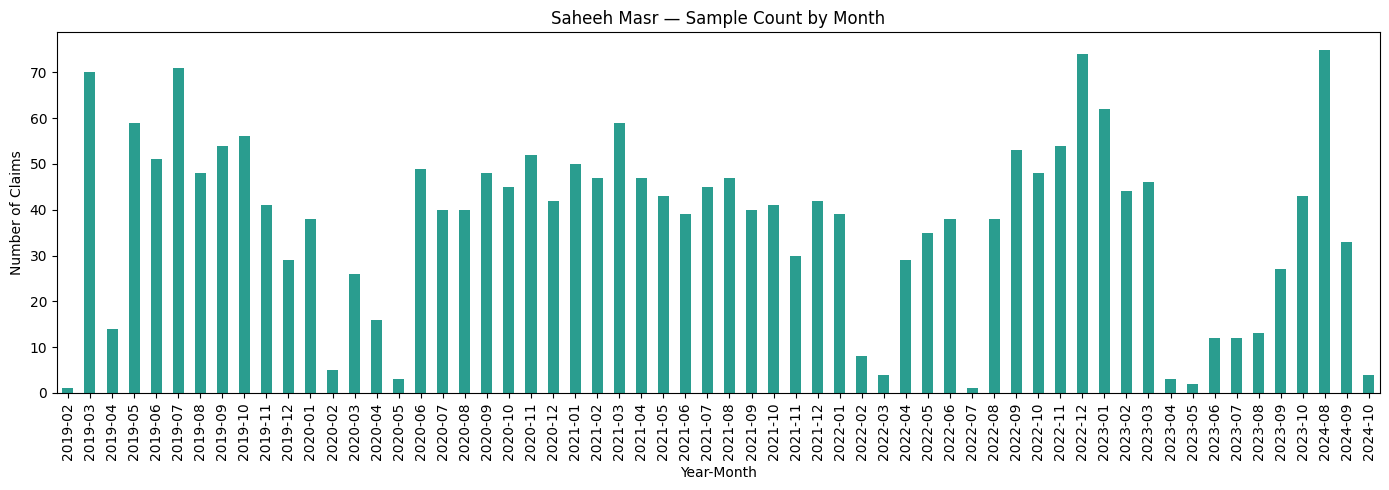

⚠️  Check: is the data concentrated in a few months (risky for splitting)
   or spread reasonably across the full range (good for splitting)?


In [ ]:
saheeh_dated['year_month'] = saheeh_dated['date_parsed'].dt.to_period('M')
monthly_counts = saheeh_dated.groupby('year_month').size()

fig, ax = plt.subplots(figsize=(14, 5))
monthly_counts.plot(kind='bar', ax=ax, color='#2A9D8F')
ax.set_title('Saheeh Masr — Sample Count by Month')
ax.set_xlabel('Year-Month')
ax.set_ylabel('Number of Claims')
plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig('saheeh_timeline.png', dpi=150, bbox_inches='tight')
plt.show()

print('⚠️  Check: is the data concentrated in a few months (risky for splitting)')
print('   or spread reasonably across the full range (good for splitting)?')

---
## 4. Find Candidate Cutoff Points

**Why:** We want a cutoff that gives a reasonable amount of data on both sides (e.g. at least 60/40 or better) — not a cutoff that leaves the test set too small to trust.

In [ ]:
# Try a few candidate split ratios and show resulting dates + sizes
candidates = [0.6, 0.65, 0.7, 0.75, 0.8]

print('Candidate cutoff points:\n')
for ratio in candidates:
    idx = int(len(saheeh_dated) * ratio)
    cutoff_date = saheeh_dated.iloc[idx]['date_parsed']
    early = saheeh_dated.iloc[:idx]
    late  = saheeh_dated.iloc[idx:]
    print(f'Split at {ratio*100:.0f}%  |  Cutoff: {cutoff_date.date()}  |  '
          f'Early: {len(early)} samples, Late: {len(late)} samples')
    print(f'   Early label balance: {dict(early["binary_label"].value_counts())}')
    print(f'   Late  label balance: {dict(late["binary_label"].value_counts())}\n')

Candidate cutoff points:

Split at 60%  |  Cutoff: 2021-10-13  |  Early: 1335 samples, Late: 890 samples
   Early label balance: {1: np.int64(1024), 0: np.int64(311)}
   Late  label balance: {1: np.int64(468), 0: np.int64(422)}

Split at 65%  |  Cutoff: 2022-01-16  |  Early: 1446 samples, Late: 779 samples
   Early label balance: {1: np.int64(1088), 0: np.int64(358)}
   Late  label balance: {1: np.int64(404), 0: np.int64(375)}

Split at 70%  |  Cutoff: 2022-06-08  |  Early: 1557 samples, Late: 668 samples
   Early label balance: {1: np.int64(1135), 0: np.int64(422)}
   Late  label balance: {1: np.int64(357), 0: np.int64(311)}

Split at 75%  |  Cutoff: 2022-09-27  |  Early: 1668 samples, Late: 557 samples
   Early label balance: {1: np.int64(1188), 0: np.int64(480)}
   Late  label balance: {1: np.int64(304), 0: np.int64(253)}

Split at 80%  |  Cutoff: 2022-12-04  |  Early: 1780 samples, Late: 445 samples
   Early label balance: {1: np.int64(1252), 0: np.int64(528)}
   Late  label balanc

---
## 5. Label Balance Confound Check

**Why this matters:** If fake/real ratio shifts heavily over time (e.g. early period mostly real, late period mostly fake), then a model's performance drop on the "late" test set could be explained by label imbalance shift rather than genuine topic/entity novelty. This needs to be ruled out or explicitly reported.

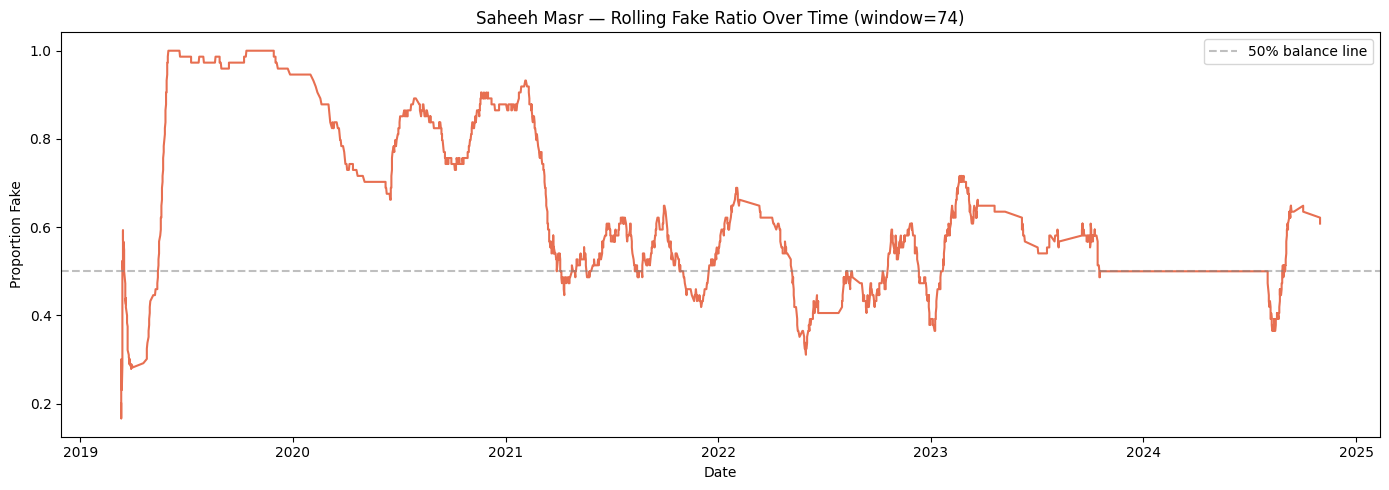

⚠️  Check: does the line stay roughly flat (good — no confound) or trend up/down
   sharply over time (bad — label shift could explain any performance drop)?


In [ ]:
# Plot fake ratio over time (rolling window to smooth noise)
saheeh_dated_sorted = saheeh_dated.sort_values('date_parsed').reset_index(drop=True)
window = max(20, len(saheeh_dated_sorted) // 30)
saheeh_dated_sorted['fake_rolling'] = saheeh_dated_sorted['binary_label'].rolling(window, min_periods=5).mean()

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(saheeh_dated_sorted['date_parsed'], saheeh_dated_sorted['fake_rolling'], color='#E76F51')
ax.axhline(0.5, color='grey', linestyle='--', alpha=0.5, label='50% balance line')
ax.set_title(f'Saheeh Masr — Rolling Fake Ratio Over Time (window={window})')
ax.set_xlabel('Date')
ax.set_ylabel('Proportion Fake')
ax.legend()
plt.tight_layout()
plt.savefig('saheeh_label_drift.png', dpi=150, bbox_inches='tight')
plt.show()

print('⚠️  Check: does the line stay roughly flat (good — no confound) or trend up/down')
print('   sharply over time (bad — label shift could explain any performance drop)?')

---
## 6. Vocabulary Drift — Is the Late Period Actually "New"?

**Why:** If early and late periods share almost all their vocabulary, a temporal split tests nothing meaningfully different from a random split. We want to see genuine OOV between the two halves, using the same method as the original cross-dataset EDA.

In [ ]:
# Use the 70% split as the reference cutoff for this analysis
SPLIT_RATIO = 0.7  # adjust based on Section 4 results if needed
split_idx = int(len(saheeh_dated) * SPLIT_RATIO)
early = saheeh_dated.iloc[:split_idx]
late  = saheeh_dated.iloc[split_idx:]
cutoff_date = saheeh_dated.iloc[split_idx]['date_parsed']

print(f'Using cutoff date: {cutoff_date.date()}')
print(f'Early (train-eligible): {len(early)} | Late (test): {len(late)}\n')

def build_vocab(texts):
    vocab = Counter()
    for t in texts:
        vocab.update(normalize_arabic(t).split())
    return vocab

early_vocab = build_vocab(early['text'])
late_vocab  = build_vocab(late['text'])

early_set = set(early_vocab.keys())
late_set  = set(late_vocab.keys())

oov_types = late_set - early_set
oov_token_count = sum(v for k, v in late_vocab.items() if k not in early_set)
total_late_tokens = sum(late_vocab.values())

print(f'Late-period vocabulary size: {len(late_set)}')
print(f'Type OOV (late words not in early): {len(oov_types)} ({len(oov_types)/len(late_set)*100:.1f}%)')
print(f'Token OOV: {oov_token_count/total_late_tokens*100:.1f}%')
print()
print('Reference from original cross-dataset EDA: VERA→Saheeh OOV was 52.3% (severe domain shift)')
print('If this temporal OOV is much lower (e.g. <20%), the split is a milder, more realistic test')
print('of true generalization within-domain — which is exactly what we want it to be.')

Using cutoff date: 2022-06-08
Early (train-eligible): 1557 | Late (test): 668

Late-period vocabulary size: 5744
Type OOV (late words not in early): 2813 (49.0%)
Token OOV: 22.8%

Reference from original cross-dataset EDA: VERA→Saheeh OOV was 52.3% (severe domain shift)
If this temporal OOV is much lower (e.g. <20%), the split is a milder, more realistic test
of true generalization within-domain — which is exactly what we want it to be.


In [ ]:
# Show top new (OOV) words in the late period — these should be genuinely new entities/events
oov_freq = {k: v for k, v in late_vocab.items() if k in oov_types}
top_oov = sorted(oov_freq.items(), key=lambda x: -x[1])[:30]

print('Top 30 words appearing in LATE period but never in EARLY period:')
for word, count in top_oov:
    print(f'  {word:20s}: {count}')

print('\n💡 Look at these: are they genuinely new entities/events (good — confirms temporal novelty)')
print('   or just rare words/typos (less meaningful)?')

Top 30 words appearing in LATE period but never in EARLY period:
  سابقًا              : 21
  أنّها               : 9
  الجنيه              : 8
  زعمت                : 8
  برج                 : 6
  نشرتها              : 6
  سين                 : 6
  وجيم                : 6
  إيدي                : 6
  لحركة               : 6
  الرياضية            : 5
  تزعم                : 5
  الأرز               : 5
  رونالدو             : 5
  ميناء               : 5
  معبر                : 5
  كوهين،              : 5
  شلبي                : 4
  تصريحًا             : 4
  زعم                 : 4
  بيانات              : 4
  منحة                : 4
  لمجموعة             : 4
  الأرجنتين           : 4
  ميسي                : 4
  مرمى                : 4
  أرباح               : 4
  الضابط              : 4
  سام                 : 4
  توكيل               : 4

💡 Look at these: are they genuinely new entities/events (good — confirms temporal novelty)
   or just rare words/typos (less meaningful)?


---
## 7. Named Entity Overlap Check (Simple Heuristic)

**Why:** The strongest evidence of true temporal generalization is genuinely new named entities (people, places, organizations) in the late period. This is a lightweight heuristic check — capitalized-equivalent Arabic proper nouns are hard to detect without a full NER pipeline, so this looks at high-frequency content words unique to each period as a proxy.

In [ ]:
# Lightweight proxy: words appearing 3+ times in late period but 0 times in early period
# are likely to be new entities, events, or topics specific to the later timeframe
frequent_new = {k: v for k, v in oov_freq.items() if v >= 3}
frequent_new_sorted = sorted(frequent_new.items(), key=lambda x: -x[1])

print(f'Words appearing 3+ times in LATE period only: {len(frequent_new_sorted)}')
print('\nTop 20 (likely new entities/events/topics specific to the test period):')
for word, count in frequent_new_sorted[:20]:
    print(f'  {word:20s}: {count}')

print('\n📋 Manually inspect a sample of late-period claims containing these words')
print('   to confirm they represent genuinely new events, not noise.')

# Show 5 example claims containing top new words for manual inspection
if frequent_new_sorted:
    top_word = frequent_new_sorted[0][0]
    examples = late[late['text'].str.contains(top_word, na=False)]['text'].head(5)
    print(f'\nExample claims containing "{top_word}":')
    for ex in examples:
        print(f'  - {ex[:120]}')

Words appearing 3+ times in LATE period only: 77

Top 20 (likely new entities/events/topics specific to the test period):
  سابقًا              : 21
  أنّها               : 9
  الجنيه              : 8
  زعمت                : 8
  برج                 : 6
  نشرتها              : 6
  سين                 : 6
  وجيم                : 6
  إيدي                : 6
  لحركة               : 6
  الرياضية            : 5
  تزعم                : 5
  الأرز               : 5
  رونالدو             : 5
  ميناء               : 5
  معبر                : 5
  كوهين،              : 5
  شلبي                : 4
  تصريحًا             : 4
  زعم                 : 4

📋 Manually inspect a sample of late-period claims containing these words
   to confirm they represent genuinely new events, not noise.

Example claims containing "سابقًا":
  - ❌ انتشر تصميم على موقع X (تويتر سابقًا) يحمل لوجو صحيفة اليوم السابع تضمن تصريحًا لرجل الأعمال نجيب ساويرس يقول فيه: "هو
  - ❌ نشر حساب باسم "سام يوسف" على موقع X "تويتر سابقًا" صو

---
## 8. Final Recommendation

In [ ]:
print('='*70)
print('  TEMPORAL SPLIT — FEASIBILITY SUMMARY')
print('='*70)
print(f"""
Date coverage:        {pct_usable:.1f}% of rows usable
Recommended cutoff:   {cutoff_date.date()}  (70% split)
Early (train-eligible): {len(early)} samples
Late (test, unseen):    {len(late)} samples

Late-period vocabulary OOV vs early: {len(oov_types)/len(late_set)*100:.1f}% (type-level)
Words appearing 3+ times only in late period: {len(frequent_new_sorted)}

Compare to original cross-dataset EDA reference points:
  VERA → Saheeh Masr OOV: 52.3% (severe domain shift)
  This temporal OOV: {len(oov_types)/len(late_set)*100:.1f}%
""")

temporal_oov = len(oov_types)/len(late_set)*100
if temporal_oov < 15:
    print('⚠️  LOW novelty — early/late periods are quite similar.')
    print('   The temporal split may not test much beyond a random split.')
    print('   Still worth running as a sanity check, but do not oversell it as a strong')
    print('   generalization test in the thesis — frame it as a complementary, lighter check.')
elif temporal_oov < 35:
    print('✅ MODERATE novelty — a meaningful but realistic generalization gap.')
    print('   This is actually an ideal result: enough novelty to be a genuine test,')
    print('   not so much that it becomes another out-of-domain problem like Saheeh Masr itself.')
else:
    print('🚨 HIGH novelty — early/late periods are quite different.')
    print('   This is a meaningful test, but check Section 6/7 to confirm this is genuine')
    print('   topic/event drift and not an artifact of small late-period sample size.')

print(f'\n✅ Proceed to build the temporal-split training notebook using cutoff: {cutoff_date.date()}')

# Save the split for reuse in the training notebook
early.to_csv('saheeh_temporal_early.csv', index=False)
late.to_csv('saheeh_temporal_late.csv', index=False)
print('✅ Saved saheeh_temporal_early.csv and saheeh_temporal_late.csv for the training notebook')

  TEMPORAL SPLIT — FEASIBILITY SUMMARY

Date coverage:        89.5% of rows usable
Recommended cutoff:   2022-06-08  (70% split)
Early (train-eligible): 1557 samples
Late (test, unseen):    668 samples

Late-period vocabulary OOV vs early: 49.0% (type-level)
Words appearing 3+ times only in late period: 77

Compare to original cross-dataset EDA reference points:
  VERA → Saheeh Masr OOV: 52.3% (severe domain shift)
  This temporal OOV: 49.0% 

🚨 HIGH novelty — early/late periods are quite different.
   This is a meaningful test, but check Section 6/7 to confirm this is genuine
   topic/event drift and not an artifact of small late-period sample size.

✅ Proceed to build the temporal-split training notebook using cutoff: 2022-06-08
✅ Saved saheeh_temporal_early.csv and saheeh_temporal_late.csv for the training notebook
